In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from identify import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, binary_dilation
from scipy.spatial.distance import cdist
from scipy.signal import detrend

In [2]:
# Load the Data's directory.
datadir_1 = 'C:/Users/txu245/Desktop/25-11-12/04_01_01.zda'
datadir_2 = 'C:/Users/txu245/Desktop/25-11-12/04_01_04.zda'

# Load the Tool Packages.
dataLoader_1 = DataLoader(datadir_1)
dataLoader_2 = DataLoader(datadir_2)
tools = Tools()
maps = Maps()
identify = Identify()

In [3]:
# Parameters setting up.
timeline = np.linspace(0, 499.5, 1000)
basePt = 194
skipPt = 50
startPt = 194
numPt = 50
stimulus = 200

In [4]:
# Data Preprocessing for data_1.
Data_1 = dataLoader_1.get_data()
Data_1 = tools.Polynomial(startPt=basePt, numPt=skipPt, Data=Data_1)
Rli_1 = dataLoader_1.get_rli()
Data_1 = tools.Rli_Division(Rli=Rli_1, Data=Data_1)
Data_1 = tools.T_filter(Data=Data_1)
Data_1 = tools.S_filter(sigma=1, Data=Data_1)
Data_ave_1 = np.mean(Data_1, axis=0)

# SNR Map for data_1. (Without Normalization)
snr_map_1 = maps.SNR_Map(startPt=startPt, numPt=numPt, Data=Data_1)

# Rli Map for data_1.
rli_high = np.array(Rli_1['rli_high'])
rli_low = np.array(Rli_1['rli_low'])

rli_1 = ((rli_high - rli_low) / 3276.8)
bad = np.where(rli_1==0)
for coor in bad:
    rli_1[coor] = 0
rli_1 = rli_1.reshape(80, 80)

In [5]:
where = np.where(snr_map_1 >= np.percentile(snr_map_1, 90))
where = np.transpose(where)

for i, coor in enumerate(where):
    if i == 0:
        laten = maps.Max_Amp_Latency(Trace=Data_ave_1[coor[0], coor[1]], startPt=startPt, numPt=numPt, stimulus=stimulus)
        evoke_1 = np.array([coor[0], coor[1]])
    else:
        if maps.Max_Amp_Latency(Trace=Data_ave_1[coor[0], coor[1]], startPt=startPt, numPt=numPt, stimulus=stimulus) <= laten:
            laten = maps.Max_Amp_Latency(Trace=Data_ave_1[coor[0], coor[1]], startPt=startPt, numPt=numPt, stimulus=stimulus)
            evoke_1 = np.array([coor[0], coor[1]])

In [6]:
# Data Preprocessing for data_2.
Data_2 = dataLoader_2.get_data()
Data_2 = tools.Polynomial(startPt=basePt, numPt=skipPt, Data=Data_2)
Rli_2 = dataLoader_2.get_rli()
Data_2 = tools.Rli_Division(Rli=Rli_2, Data=Data_2)
Data_2 = tools.T_filter(Data=Data_2)
Data_2 = tools.S_filter(sigma=1, Data=Data_2)
Data_ave_2 = np.mean(Data_2, axis=0)

# SNR Map for data_2. (Without Normalization)
snr_map_2 = maps.SNR_Map(startPt=startPt, numPt=numPt, Data=Data_2)

# Rli Map for data_2.
rli_high = np.array(Rli_2['rli_high'])
rli_low = np.array(Rli_2['rli_low'])

rli_2 = ((rli_high - rli_low) / 3276.8)
bad = np.where(rli_2==0)
for coor in bad:
    rli_2[coor] = 0
rli_2 = rli_2.reshape(80, 80)

In [7]:
where = np.where(snr_map_2 >= np.percentile(snr_map_2, 90))
where = np.transpose(where)

for i, coor in enumerate(where):
    if i == 0:
        laten = maps.Max_Amp_Latency(Trace=Data_ave_2[coor[0], coor[1]], startPt=startPt, numPt=numPt, stimulus=stimulus)
        evoke_2 = np.array([coor[0], coor[1]])
    else:
        if maps.Max_Amp_Latency(Trace=Data_ave_2[coor[0], coor[1]], startPt=startPt, numPt=numPt, stimulus=stimulus) <= laten:
            laten = maps.Max_Amp_Latency(Trace=Data_ave_2[coor[0], coor[1]], startPt=startPt, numPt=numPt, stimulus=stimulus)
            evoke_2 = np.array([coor[0], coor[1]])

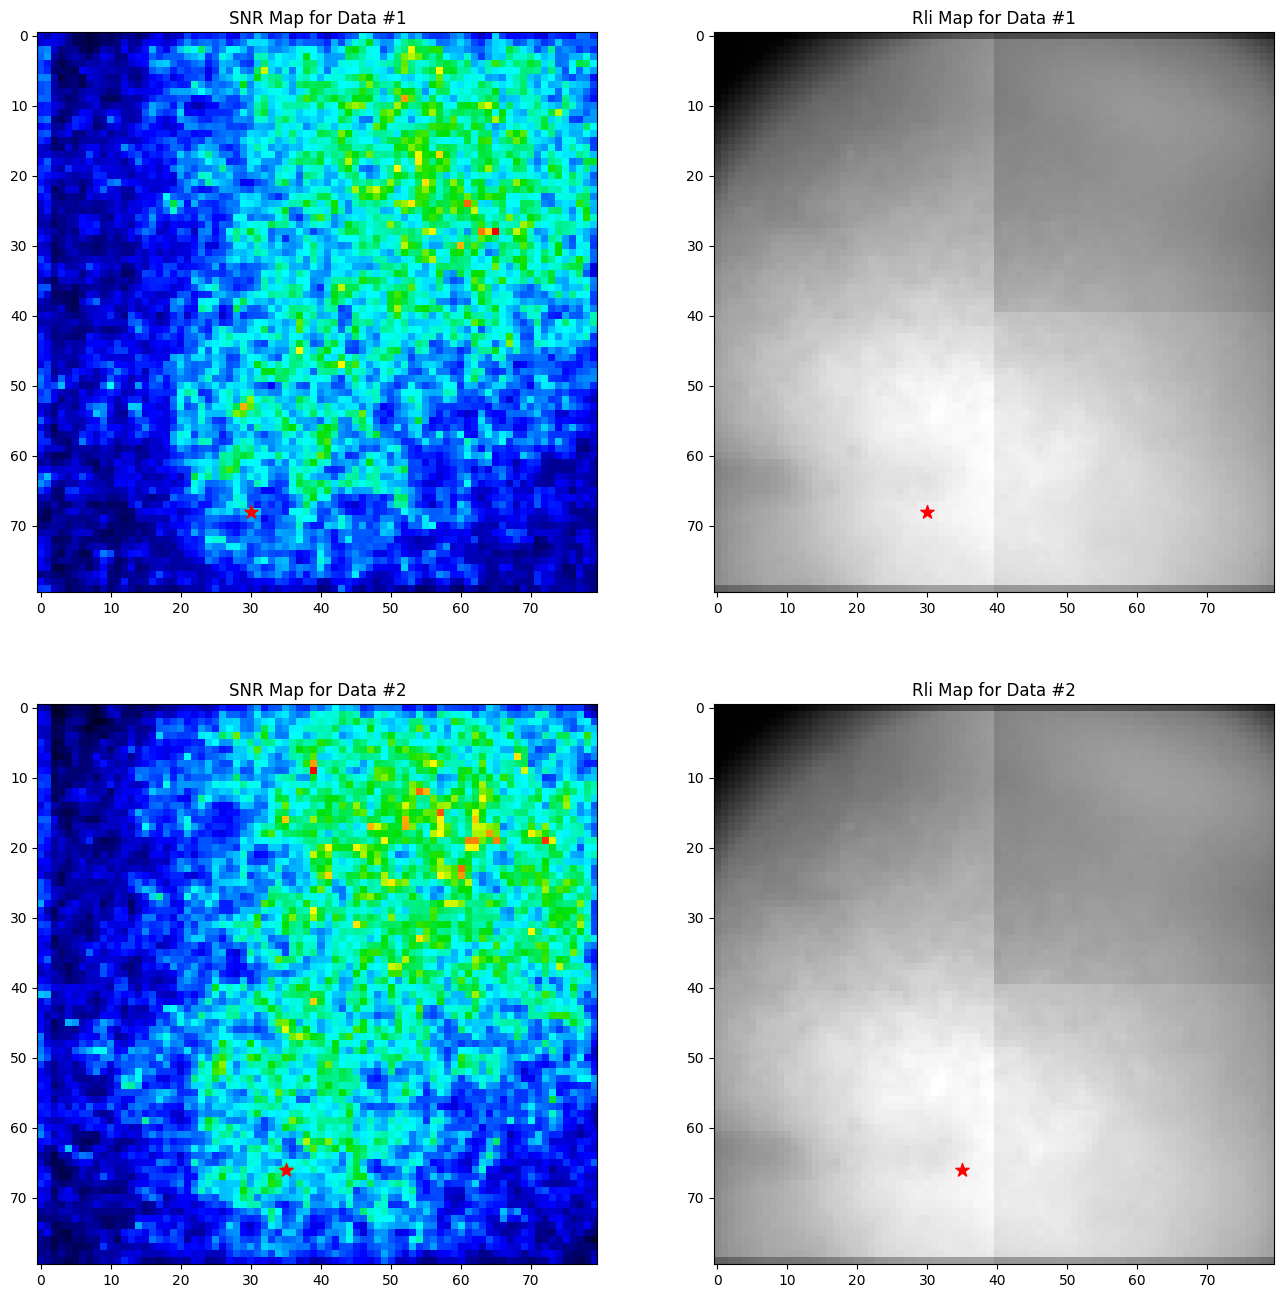

In [8]:
# Plotting the SNR Maps and Rli Maps for Data #1 and Data #2.
plt.subplots(2, 2, figsize=(16, 16))

# SNR Map for Data #1.
ax1 = plt.subplot(2, 2, 1)
ax1.imshow(snr_map_1 / np.max(snr_map_1), vmin=0, vmax=1, cmap=maps.colorbar())
ax1.set_title('SNR Map for Data #1')
ax1.scatter(evoke_1[1], evoke_1[0], color='red', s=100, marker='*')

# RLi Map for Data #1.
ax2 = plt.subplot(2, 2, 2)
ax2.imshow(rli_1, cmap='gray')
ax2.set_title('Rli Map for Data #1')
ax2.scatter(evoke_1[1], evoke_1[0], color='red', s=100, marker='*')

# SNR Map for Data #2.
ax3 = plt.subplot(2, 2, 3)
ax3.imshow(snr_map_2 / np.max(snr_map_2), vmin=0, vmax=1, cmap=maps.colorbar())
ax3.set_title('SNR Map for Data #2')
ax3.scatter(evoke_2[1], evoke_2[0], color='red', s=100, marker='*')

# Rli Map for Data #2.
ax4 = plt.subplot(2, 2, 4)
ax4.imshow(rli_2, cmap='gray')
ax4.set_title('Rli Map for Data #2')
ax4.scatter(evoke_2[1], evoke_2[0], color='red', s=100, marker='*')

plt.show()

In [9]:
# Single Cell Identification for Data #1.
candidates_1 = identify.candidates(Data_ave=Data_ave_1, cutoff=95, startPt=startPt, numPt=numPt)
candidates_1 = identify.select_non_overlap(candidates=candidates_1, snr_map=snr_map_1)
candidates_1 = sorted(candidates_1, key=lambda x: (x[0], x[1]))

In [10]:
# Single Cell Identification for Data #2.
candidates_2 = identify.candidates(Data_ave=Data_ave_2, cutoff=95, startPt=startPt, numPt=numPt)
candidates_2 = identify.select_non_overlap(candidates=candidates_2, snr_map=snr_map_2)
candidates_2 = sorted(candidates_2, key=lambda x: (x[0], x[1]))

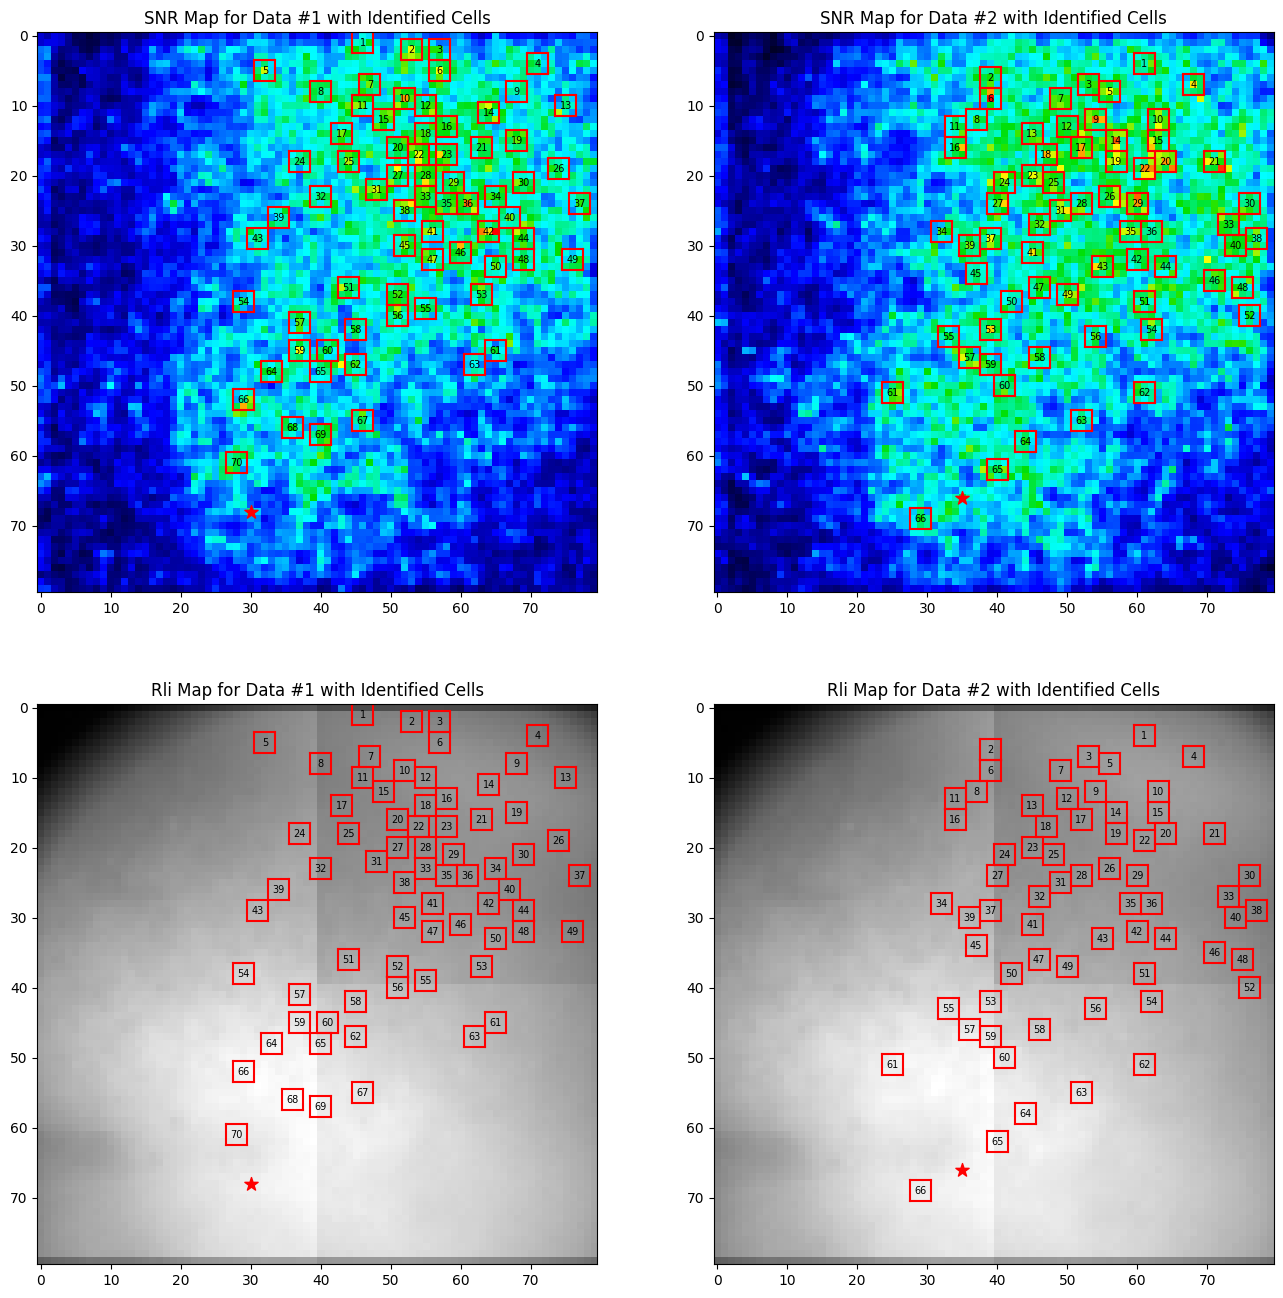

In [11]:
# Parameters setting.
color = 'red'
linewidth = 1.5
index_1 = [(x[0], x[1]) for x in candidates_1]
index_2 = [(x[0], x[1]) for x in candidates_2]

# Visualization of the identified cells on the SNR Maps and Rli Maps for Data #1 and Data #2.
plt.subplots(2, 2, figsize=(16, 16))

# SNR Map for Data #1 with identified cells.
ax1 = plt.subplot(2, 2, 1)
ax1.imshow(snr_map_1 / np.max(snr_map_1), vmin=0, vmax=1, cmap=maps.colorbar())
ax1.scatter(evoke_1[1], evoke_1[0], color='red', s=100, marker='*')
ax1.set_title('SNR Map for Data #1 with Identified Cells')
for i, coor in enumerate(index_1):

    #  Coordinates for columns and rows.   
    r = coor[1]
    c = coor[0]

    # Pixel boundaries.
    top    = r - 1.5
    bottom = r + 1.5
    left   = c - 1.5
    right  = c + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

# SNR Map for Dasta #2 with identified cells.
ax2 = plt.subplot(2, 2, 2)
ax2.imshow(snr_map_2 / np.max(snr_map_2), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.scatter(evoke_2[1], evoke_2[0], color='red', s=100, marker='*')
ax2.set_title('SNR Map for Data #2 with Identified Cells')
for i, coor in enumerate(index_2):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

# Rli Map for Data #1 with identified cells.
ax3 = plt.subplot(2, 2, 3)  
ax3.imshow(rli_1, cmap='gray')
ax3.set_title('Rli Map for Data #1 with Identified Cells')
ax3.scatter(evoke_1[1], evoke_1[0], color='red', s=100, marker='*')
for i, coor in enumerate(index_1):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax3.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax3.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax3.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax3.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax3.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

# Rli Map for Data #2 with identified cells.
ax4 = plt.subplot(2, 2, 4)  
ax4.imshow(rli_2, cmap='gray')
ax4.scatter(evoke_2[1], evoke_2[0], color='red', s=100, marker='*')
ax4.set_title('Rli Map for Data #2 with Identified Cells')
for i, coor in enumerate(index_2):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax4.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax4.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax4.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax4.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax4.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

plt.show()

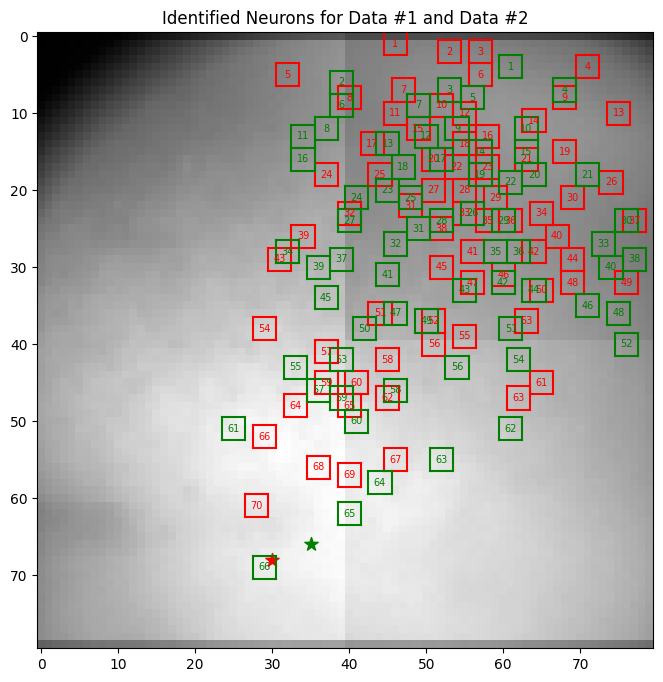

In [12]:
plt.figure(figsize=(8, 8))
plt.imshow(rli_1, cmap='gray')
plt.scatter(evoke_1[1], evoke_1[0], color='red', s=100, marker="*")
plt.scatter(evoke_2[1], evoke_2[0], color='green', s=100, marker='*')
plt.title('Identified Neurons for Data #1 and Data #2')

for i, coor in enumerate(index_1):

    #  Coordinates for columns and rows.   
    r = coor[1]
    c = coor[0]

    # Pixel boundaries.
    top    = r - 1.5
    bottom = r + 1.5
    left   = c - 1.5
    right  = c + 1.5

    # Draw square contour.
    plt.plot([top, top], [left, right], color=color, linewidth=linewidth)
    plt.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    plt.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    plt.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    plt.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='red')

for i, coor in enumerate(index_2):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    plt.plot([top, top], [left, right], color='green', linewidth=linewidth)
    plt.plot([bottom, bottom], [left, right], color='green', linewidth=linewidth)
    plt.plot([top, bottom], [left, left], color='green', linewidth=linewidth)
    plt.plot([top, bottom], [right, right], color='green', linewidth=linewidth)

    # Label index.
    plt.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='green')

plt.show()

Neuron 1 and Neuron 4 are correlated with a positive slope, and the P-Value is: 0.041049 , distance is: 151.07613974417006 um.
Neuron 1 and Neuron 44 are correlated with a positive slope, and the P-Value is: 0.01693 , distance is: 217.41205118392125 um.
Neuron 1 and Neuron 65 are correlated with a positive slope, and the P-Value is: 0.003034 , distance is: 284.2885857715712 um.
Neuron 2 and Neuron 48 are correlated with a positive slope, and the P-Value is: 0.018467 , distance is: 204.0 um.
Neuron 2 and Neuron 50 are correlated with a positive slope, and the P-Value is: 0.023915 , distance is: 199.44924166313592 um.
Neuron 2 and Neuron 60 are correlated with a positive slope, and the P-Value is: 0.028082 , distance is: 267.8581714265966 um.
Neuron 4 and Neuron 16 are correlated with a positive slope, and the P-Value is: 0.014101 , distance is: 94.86832980505137 um.
Neuron 4 and Neuron 50 are correlated with a positive slope, and the P-Value is: 0.024186 , distance is: 177.6851147395301

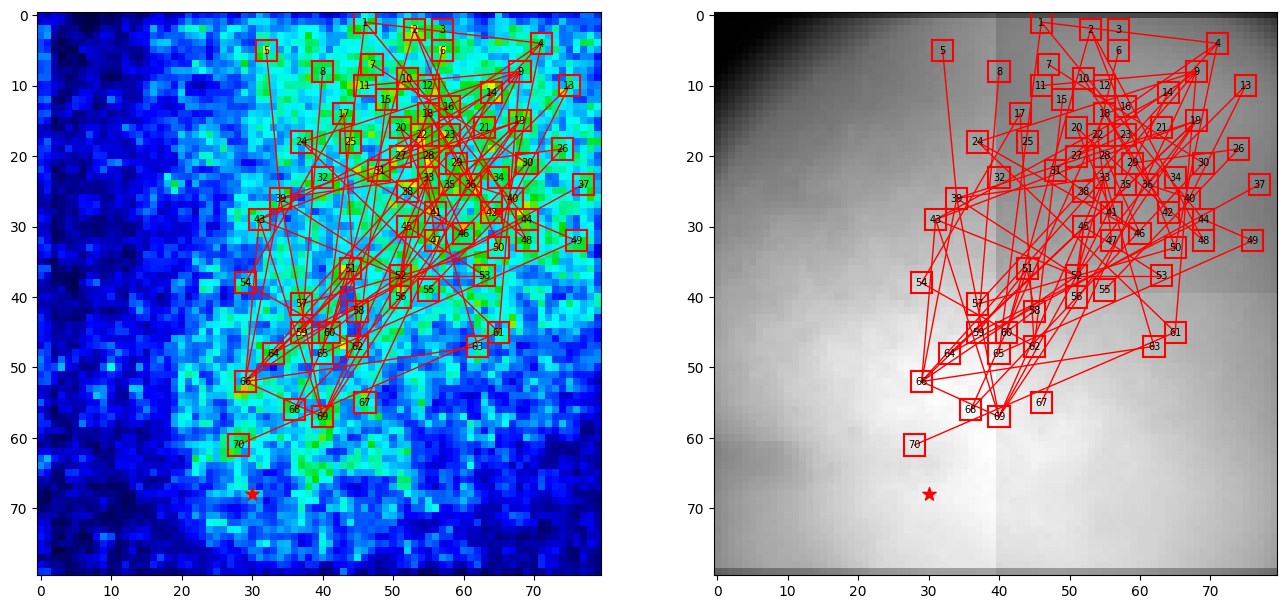

80 pairs are correlated.
Totally 2415 pairs.


In [13]:
length_1 = len(candidates_1)
trial = Data_1.shape[0]
latency_1 = np.zeros((length_1, trial))
connection_1 = np.zeros(length_1, dtype=int)
count = 0

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map_1 / np.max(snr_map_1), vmin=0, vmax=1, cmap=maps.colorbar())
ax1.scatter(evoke_1[1], evoke_1[0], color='red', s=100, marker='*')
ax2.imshow(rli_1, cmap='gray')
ax2.scatter(evoke_1[1], evoke_1[0], color='red', s=100, marker='*')

for i, coor in enumerate(index_1):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

for i in range(length_1):
    for j in range(trial):
        
        data_tem = []
        for coor in candidates_1[i][3]:
            data_tem.append(Data_1[j, coor[0], coor[1], :])
        data_tem = np.array(data_tem)
        Trace = np.mean(data_tem, axis=0)
        latency_1[i][j] = maps.Max_Amp_Latency(Trace=Trace, startPt=startPt, numPt=numPt)

for i in range(length_1-1):
    for j in range(i+1, length_1):
        
        dist = np.sqrt((index_1[i][0] - index_1[j][0])**2 + (index_1[i][1] - index_1[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_1[i], latency_1[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index_1[i]
            loc_2 = index_1[j]
            connection_1[i] = connection_1[i] + 1
            connection_1[j] = connection_1[j] + 1
            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

plt.show()

print(count, 'pairs are correlated.')
print('Totally', int(length_1*(length_1-1)/2), 'pairs.')

In [14]:
np.mean(connection_1)

np.float64(2.2857142857142856)

Neuron 1 and Neuron 37 are correlated with a positive slope, and the P-Value is: 0.049773 , distance is: 199.80990966416056 um.
Neuron 1 and Neuron 66 are correlated with a positive slope, and the P-Value is: 0.040021 , distance is: 434.69989648031896 um.
Neuron 3 and Neuron 7 are correlated with a positive slope, and the P-Value is: 0.033101 , distance is: 26.832815729997478 um.
Neuron 3 and Neuron 15 are correlated with a positive slope, and the P-Value is: 0.049672 , distance is: 76.83749084919418 um.
Neuron 3 and Neuron 16 are correlated with a positive slope, and the P-Value is: 0.019733 , distance is: 126.14277624977183 um.
Neuron 3 and Neuron 18 are correlated with a positive slope, and the P-Value is: 0.010857 , distance is: 69.97142273814362 um.
Neuron 3 and Neuron 55 are correlated with a positive slope, and the P-Value is: 0.026817 , distance is: 247.09512338368802 um.
Neuron 4 and Neuron 41 are correlated with a positive slope, and the P-Value is: 0.03276 , distance is: 199

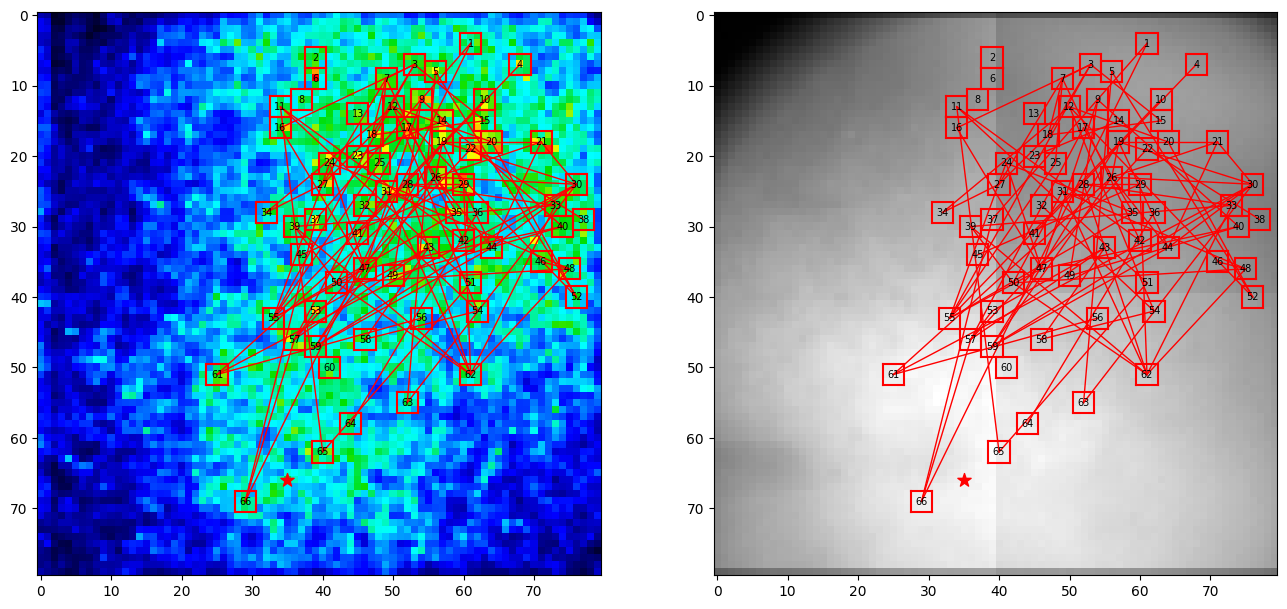

87 pairs are correlated.
Totally 2145 pairs.


In [15]:
length_2 = len(candidates_2)
trial = Data_2.shape[0]
latency_2 = np.zeros((length_2, trial))
connection_2 = np.zeros(length_2, dtype=int)
count = 0

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map_2 / np.max(snr_map_2), vmin=0, vmax=1, cmap=maps.colorbar())
ax1.scatter(evoke_2[1], evoke_2[0], color='red', s=100, marker='*')
ax2.imshow(rli_2, cmap='gray')
ax2.scatter(evoke_2[1], evoke_2[0], color='red', s=100, marker='*')

for i, coor in enumerate(index_2):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

for i in range(length_2):
    for j in range(trial):
        
        data_tem = []
        for coor in candidates_2[i][3]:
            data_tem.append(Data_2[j, coor[0], coor[1], :])
        data_tem = np.array(data_tem)
        Trace = np.mean(data_tem, axis=0)
        latency_2[i][j] = maps.Max_Amp_Latency(Trace=Trace, startPt=startPt, numPt=numPt)

for i in range(length_2-1):
    for j in range(i+1, length_2):
        
        dist = np.sqrt((index_2[i][0] - index_2[j][0])**2 + (index_2[i][1] - index_2[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_2[i], latency_2[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index_2[i]
            loc_2 = index_2[j]
            connection_2[i] = connection_2[i] + 1
            connection_2[j] = connection_2[j] + 1
            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

plt.show()

print(count, 'pairs are correlated.')
print('Totally', int(length_2*(length_2-1)/2), 'pairs.')

In [16]:
np.mean(connection_2)

np.float64(2.6363636363636362)

Neuron 50 and Neuron 2 are correlated with a positive slope, and the P-Value is: 0.023915 , distance is: 199.44924166313592 um.
Neuron 50 and Neuron 4 are correlated with a positive slope, and the P-Value is: 0.024186 , distance is: 177.68511473953018 um.
Neuron 50 and Neuron 57 are correlated with a positive slope, and the P-Value is: 0.002574 , distance is: 174.72263734273244 um.


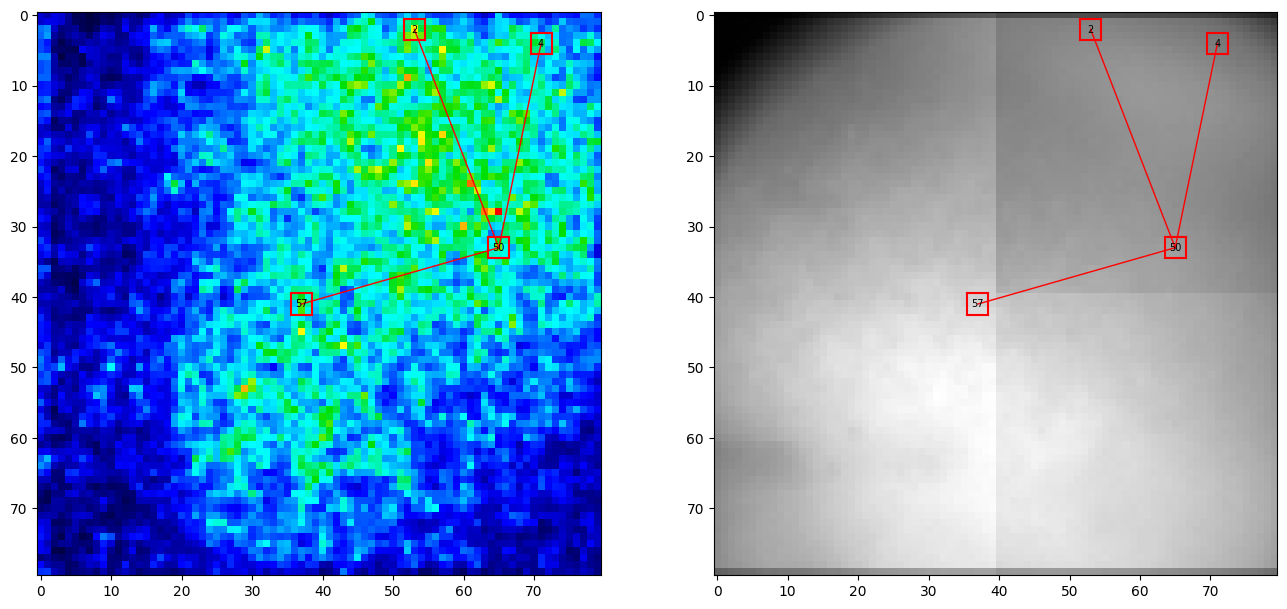

In [32]:
neuro_label_1 = 50

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map_1 / np.max(snr_map_1), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.imshow(rli_1, cmap='gray')


top = index_1[neuro_label_1-1][1] - 1.5
bottom = index_1[neuro_label_1-1][1] + 1.5
left = index_1[neuro_label_1-1][0] - 1.5
right = index_1[neuro_label_1-1][0] + 1.5

ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax1.annotate(str(neuro_label_1), xy=(index_1[neuro_label_1-1][1], index_1[neuro_label_1-1][0]), ha='center', va='center', fontsize=7, color='black')

ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax2.annotate(str(neuro_label_1), xy=(index_1[neuro_label_1-1][1], index_1[neuro_label_1-1][0]), ha='center', va='center', fontsize=7, color='black')

for i in range(length_1):

    if i == neuro_label_1 - 1:
        continue
    else:
        dist = np.sqrt((index_1[i][0] - index_1[neuro_label_1-1][0])**2 + (index_1[i][1] - index_1[neuro_label_1-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_1[i], latency_1[neuro_label_1-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label_1, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index_1[i]
            loc_2 = index_1[neuro_label_1-1]

            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax1.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

            ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax2.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

plt.show()

Neuron 42 and Neuron 7 are correlated with a positive slope, and the P-Value is: 0.010428 , distance is: 152.97058540778355 um.
Neuron 42 and Neuron 11 are correlated with a positive slope, and the P-Value is: 0.044042 , distance is: 193.2149062572554 um.


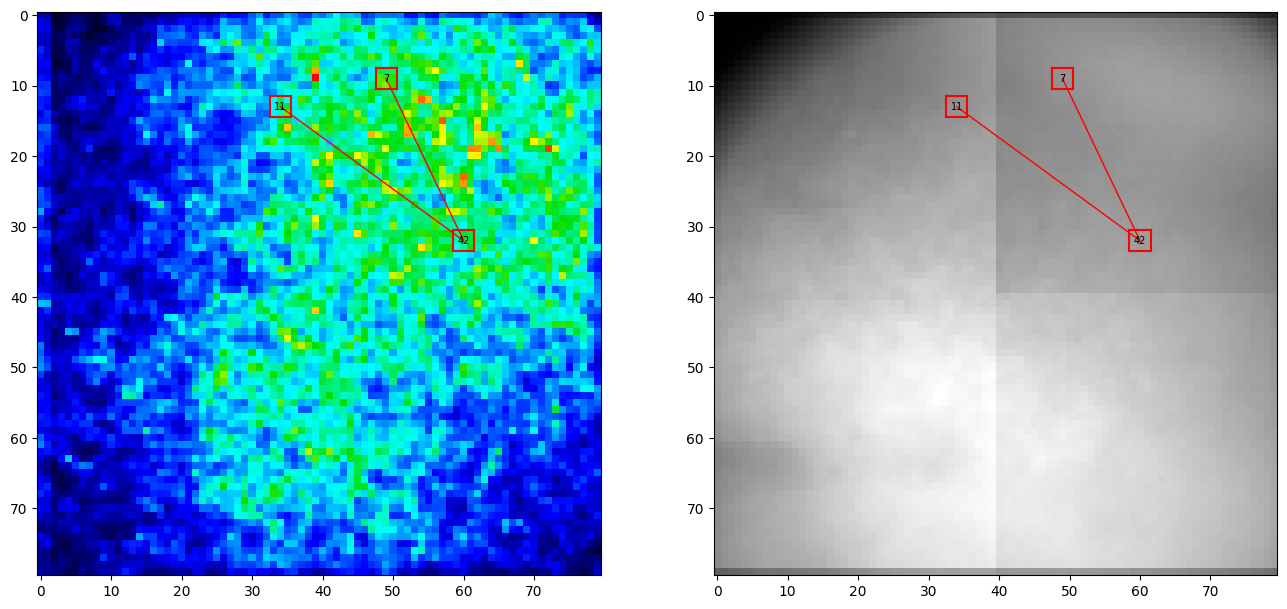

In [26]:
neuro_label_2 = 42

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map_2 / np.max(snr_map_2), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.imshow(rli_2, cmap='gray')

top = index_2[neuro_label_2-1][1] - 1.5
bottom = index_2[neuro_label_2-1][1] + 1.5
left = index_2[neuro_label_2-1][0] - 1.5
right = index_2[neuro_label_2-1][0] + 1.5

ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax1.annotate(str(neuro_label_2), xy=(index_2[neuro_label_2-1][1], index_2[neuro_label_2-1][0]), ha='center', va='center', fontsize=7, color='black')

ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax2.annotate(str(neuro_label_2), xy=(index_2[neuro_label_2-1][1], index_2[neuro_label_2-1][0]), ha='center', va='center', fontsize=7, color='black')

for i in range(length_2):

    if i == neuro_label_2 - 1:
        continue
    else:
        dist = np.sqrt((index_2[i][0] - index_2[neuro_label_2-1][0])**2 + (index_2[i][1] - index_2[neuro_label_2-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_2[i], latency_2[neuro_label_2-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label_2, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index_2[i]
            loc_2 = index_2[neuro_label_2-1]

            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax1.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

            ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax2.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

plt.show()     

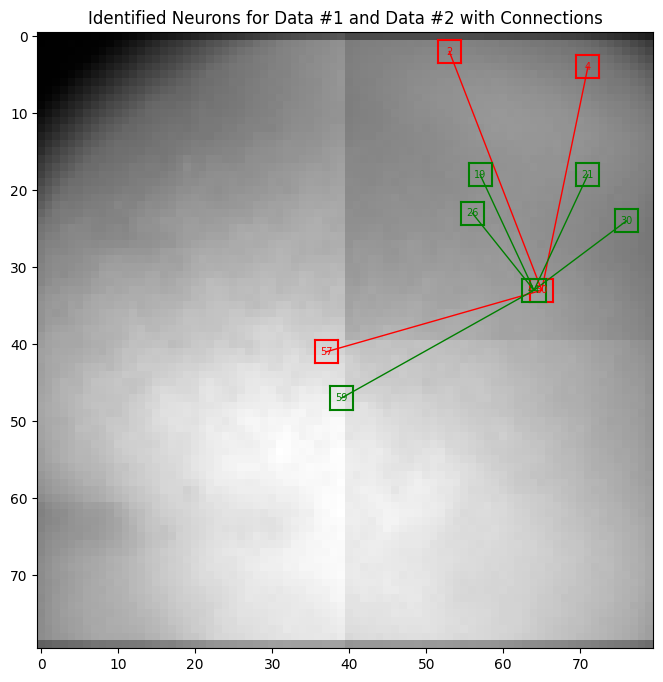

In [31]:
neuro_label_1 = 50
neuro_label_2 = 44

color_1 = 'red'
color_2 = 'green'

plt.figure(figsize=(8, 8))
plt.imshow(rli_1, cmap='gray')
plt.title('Identified Neurons for Data #1 and Data #2 with Connections')

top = index_1[neuro_label_1-1][1] - 1.5
bottom = index_1[neuro_label_1-1][1] + 1.5
left = index_1[neuro_label_1-1][0] - 1.5
right = index_1[neuro_label_1-1][0] + 1.5

plt.plot([top, top], [left, right], color=color_1, linewidth=linewidth)
plt.plot([bottom, bottom], [left, right], color=color_1, linewidth=linewidth)
plt.plot([top, bottom], [left, left], color=color_1, linewidth=linewidth)
plt.plot([top, bottom], [right, right], color=color_1, linewidth=linewidth)
plt.annotate(str(neuro_label_1), xy=(index_1[neuro_label_1-1][1], index_1[neuro_label_1-1][0]), ha='center', va='center', fontsize=7, color='red')

for i in range(length_1):

    if i == neuro_label_1 - 1:
        continue
    else:
        dist = np.sqrt((index_1[i][0] - index_1[neuro_label_1-1][0])**2 + (index_1[i][1] - index_1[neuro_label_1-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_1[i], latency_1[neuro_label_1-1])

        if pValue <=0.05 and Slope > 0:
            loc_1 = index_1[i]
            loc_2 = index_1[neuro_label_1-1]

            plt.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            plt.plot([top, top], [left, right], color=color_1, linewidth=linewidth)
            plt.plot([bottom, bottom], [left, right], color=color_1, linewidth=linewidth)
            plt.plot([top, bottom], [left, left], color=color_1, linewidth=linewidth)
            plt.plot([top, bottom], [right, right], color=color_1, linewidth=linewidth)
            plt.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='red')

top = index_2[neuro_label_2-1][1] - 1.5
bottom = index_2[neuro_label_2-1][1] + 1.5
left = index_2[neuro_label_2-1][0] - 1.5
right = index_2[neuro_label_2-1][0] + 1.5

plt.plot([top, top], [left, right], color=color_2, linewidth=linewidth)
plt.plot([bottom, bottom], [left, right], color=color_2, linewidth=linewidth)
plt.plot([top, bottom], [left, left], color=color_2, linewidth=linewidth)
plt.plot([top, bottom], [right, right], color=color_2, linewidth=linewidth)
plt.annotate(str(neuro_label_2), xy=(index_2[neuro_label_2-1][1], index_2[neuro_label_2-1][0]), ha='center', va='center', fontsize=7, color='green')

for i in range(length_2):

    if i == neuro_label_2 - 1:
        continue
    else:
        dist = np.sqrt((index_2[i][0] - index_2[neuro_label_2-1][0])**2 + (index_2[i][1] - index_2[neuro_label_2-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_2[i], latency_2[neuro_label_2-1])

        if pValue <=0.05 and Slope > 0:
            loc_1 = index_2[i]
            loc_2 = index_2[neuro_label_2-1]

            plt.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='green', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            plt.plot([top, top], [left, right], color=color_2, linewidth=linewidth)
            plt.plot([bottom, bottom], [left, right], color=color_2, linewidth=linewidth)
            plt.plot([top, bottom], [left, left], color=color_2, linewidth=linewidth)
            plt.plot([top, bottom], [right, right], color=color_2, linewidth=linewidth)
            plt.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='green')

plt.show() 

In [41]:
np.abs(latency_1[50-1] - latency_1[2-1])

array([1.5, 0.5, 1.5, 9. , 1.5, 1. , 3. , 1.5, 0.5, 2. ])

In [38]:
latency_2[44-1] - latency_2[59-1]

array([ 3.5,  3.5,  5. ,  3. , 10. ,  2.5,  4.5, 10.5,  4. ,  6. ])

In [33]:
coor_1, coor_2 = index_1[49]
Amplitude_1 = np.max(Data_ave_1[coor_1, coor_2, :])
print(Amplitude_1)

0.00714530059204124


In [34]:
coor_1, coor_2 = index_2[43]
Amplitude_2 = np.max(Data_ave_2[coor_1, coor_2, :])
print(Amplitude_2)

0.008136868900983633


In [23]:
coor_1, coor_2 = index_1[56]
Amplitude_1_1 = np.max(Data_ave_1[coor_1, coor_2, :])
print(Amplitude_1_1)

0.006665343081646513


In [24]:
coor_1, coor_2 = index_2[58]
Amplitude_2_1 = np.max(Data_ave_2[coor_1, coor_2, :])
print(Amplitude_2_1)

0.0067060386151519035
